In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
# Download the RAVDESS dataset
print("Downloading RAVDESS dataset...")
dataset_path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Dataset downloaded to: /kaggle/input/ravdess-emotional-speech-audio


In [ ]:
import numpy as np
import pandas as pd
import os
import glob
import sys
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# Emotion mapping from RAVDESS documentation
emotions = {
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

# --- THIS IS THE CORRECTED PATH ---
DATA_PATH = '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/'
# ---------------------------------

# We set a fixed length for all audio files (in terms of feature frames)
# 3 seconds of audio with default librosa settings gives ~130 frames
MAX_PAD_LEN = 130

def extract_features_sequential(file_path):
    """
    Extracts sequential features (MFCC, Chroma, Mel) from an audio file.
    Pads or truncates the sequence to MAX_PAD_LEN.
    """
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3, offset=0.5)

        # Extract features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        mel = librosa.feature.melspectrogram(y=y, sr=sr)

        # --- Feature processing ---
        # To combine them, we'll transpose so time is the first dimension
        # (time, features)
        features = np.concatenate((mfccs.T, chroma.T, mel.T), axis=1)

        # Pad or truncate features
        if features.shape[0] < MAX_PAD_LEN:
            # Pad with zeros
            pad_width = MAX_PAD_LEN - features.shape[0]
            features = np.pad(features, ((0, pad_width), (0, 0)), mode='constant')
        else:
            # Truncate
            features = features[:MAX_PAD_LEN, :]

        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:
X, y = [], []
print("Starting sequential feature extraction...")

# Loop through all actor directories
for actor_dir in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor_dir)
    if os.path.isdir(actor_path):
        # Find all .wav files in the actor's directory
        for file_name in glob.glob(os.path.join(actor_path, '*.wav')):
            base_name = os.path.basename(file_name)
            parts = base_name.split('-')
            emotion_code = parts[2]

            if emotion_code in emotions:
                # Use the new sequential feature extractor
                features = extract_features_sequential(file_name)

                if features is not None:
                    X.append(features)
                    y.append(emotions[emotion_code])

print(f"Finished feature extraction. Loaded {len(X)} samples.")

Starting sequential feature extraction...
Finished feature extraction. Loaded 1440 samples.


In [ ]:
# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

# Encode the string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-hot encode the integer labels
ohe = OneHotEncoder()
y_onehot = ohe.fit_transform(y_encoded.reshape(-1, 1)).toarray()

# --- Scaling sequential data ---
# We need to scale the features (dimension 2)
# 1. Get shape
n_samples, n_timesteps, n_features = X.shape

# 2. Reshape to 2D (samples * timesteps, features)
X_reshaped = X.reshape(-1, n_features)

# 3. Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled_reshaped = scaler.fit_transform(X_reshaped)

# 4. Reshape back to 3D (samples, timesteps, features)
X_scaled = X_scaled_reshaped.reshape(n_samples, n_timesteps, n_features)
# -------------------------------

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot)

# We need to save the scaler and encoders
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('le.pkl', 'wb') as f:
    pickle.dump(le, f)
with open('ohe.pkl', 'wb') as f:
    pickle.dump(ohe, f)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1152, 130, 180)
y_train shape: (1152, 8)
X_test shape: (288, 130, 180)
y_test shape: (288, 8)


In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional, Conv1D, MaxPooling1D

input_shape = (X_train.shape[1], X_train.shape[2]) # (timesteps, features)
num_classes = y_train.shape[1]

model = Sequential()

# --- CNN Layers ---
# 1st Conv Block
model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# 2nd Conv Block
model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.3))

# 3rd Conv Block
model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# --- LSTM Layers ---
# The output of the CNN is a new sequence, which we feed to the LSTM
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(64)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# --- Fully Connected Layers ---
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 130, 256)       │       230,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 130, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 65, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 65, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 33, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 33, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 17, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 17, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 17, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 809,992 (3.09 MB)

 Trainable params: 808,200 (3.08 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr]
)

# Save the trained model
model.save('ser_model.keras')
print("Model trained and saved as 'ser_model.h5'")

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.2081 - loss: 2.5665 - val_accuracy: 0.1354 - val_loss: 2.0724 - learning_rate: 0.0010
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3245 - loss: 2.0031 - val_accuracy: 0.1597 - val_loss: 1.9814 - learning_rate: 0.0010
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4498 - loss: 1.5872 - val_accuracy: 0.2882 - val_loss: 1.8913 - learning_rate: 0.0010
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4504 - loss: 1.4883 - val_accuracy: 0.3194 - val_loss: 1.8396 - learning_rate: 0.0010
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5552 - loss: 1.2390 - val_accuracy: 0.3403 - val_loss: 1.7886 - learning_rate: 0.0010
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5928 - loss: 1.1437 - val_accuracy: 0.3542 - val_loss: 1.7384 - learning_rate: 0.0010
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6720 - loss: 0.9304 - 

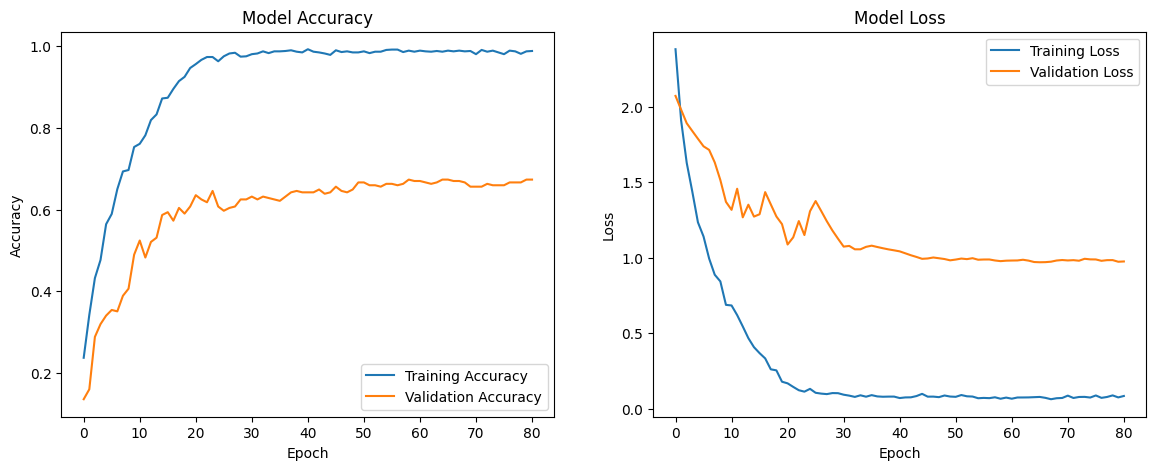

In [ ]:
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6939 - loss: 0.9544

Test Accuracy: 67.36%
Test Loss: 0.9701


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


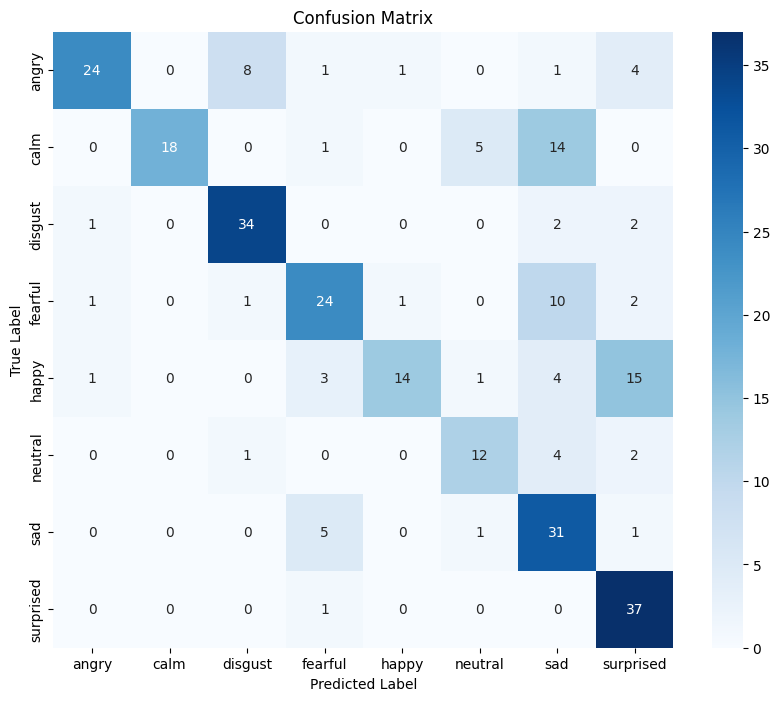

In [ ]:
# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot y_test back to class labels
y_true = np.argmax(y_test, axis=1)

# Get the class names from the label encoder
class_names = le.classes_

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))


--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.89      0.62      0.73        39
        calm       1.00      0.47      0.64        38
     disgust       0.77      0.87      0.82        39
     fearful       0.69      0.62      0.65        39
       happy       0.88      0.37      0.52        38
     neutral       0.63      0.63      0.63        19
         sad       0.47      0.82      0.60        38
   surprised       0.59      0.97      0.73        38

    accuracy                           0.67       288
   macro avg       0.74      0.67      0.66       288
weighted avg       0.75      0.67      0.67       288



In [ ]:
import numpy as np

# --- Change this number to test different audio files ---
sample_index = 5
# ----------------------------------------------------

# 1. Get a single sample from the test set
test_sample = X_test[sample_index]
true_label_onehot = y_test[sample_index]

# 2. Reshape it for the model (add a "batch" dimension)
# Shape becomes (1, timesteps, features)
test_sample_reshaped = np.expand_dims(test_sample, axis=0)

# 3. Predict
prediction_probs = model.predict(test_sample_reshaped)

# 4. Decode the prediction
prediction_index = np.argmax(prediction_probs, axis=1)
predicted_emotion = le.inverse_transform(prediction_index)[0]

# 5. Decode the true label
true_label_index = np.argmax(true_label_onehot)
true_emotion = le.classes_[true_label_index] # A direct way to use the label encoder

# 6. Print the results
print(f"--- Testing Sample #{sample_index} ---")
print(f"   Model Predicted: {predicted_emotion.upper()}")
print(f"    Actual Emotion: {true_emotion.upper()}")

# Optional: Show confidence scores
print("\nConfidence:")
for i, emotion in enumerate(le.classes_):
    print(f"  {emotion.capitalize()}: {prediction_probs[0][i] * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
--- Testing Sample #5 ---
   Model Predicted: DISGUST
    Actual Emotion: DISGUST

Confidence:
  Angry: 0.19%
  Calm: 0.12%
  Disgust: 97.26%
  Fearful: 0.09%
  Happy: 0.03%
  Neutral: 0.20%
  Sad: 0.62%
  Surprised: 1.49%


In [ ]:
import numpy as np

# --- Set how many samples you want to test ---
num_to_test = 10
# -------------------------------------------

print(f"--- Testing First {num_to_test} Samples from the Test Set ---")

for sample_index in range(num_to_test):
    # 1. Get the sample
    test_sample = X_test[sample_index]
    true_label_onehot = y_test[sample_index]

    # 2. Reshape for the model
    test_sample_reshaped = np.expand_dims(test_sample, axis=0)

    # 3. Predict
    prediction_probs = model.predict(test_sample_reshaped, verbose=0) # verbose=0 hides the progress bar
    prediction_index = np.argmax(prediction_probs, axis=1)
    predicted_emotion = le.inverse_transform(prediction_index)[0]

    # 4. Get true label
    true_label_index = np.argmax(true_label_onehot)
    true_emotion = le.classes_[true_label_index]

    # 5. Print the result
    print(f"\nSample #{sample_index}:")
    print(f"  -> Model Predicted: {predicted_emotion.upper()}")
    print(f"  -> Actual Emotion:  {true_emotion.upper()}")

    # Show a checkmark or X for an easy visual cue
    if predicted_emotion == true_emotion:
        print("  -> Result: ✅ CORRECT")
    else:
        print(f"  -> Result: ❌ INCORRECT (Predicted {predicted_emotion}, was {true_emotion})")

print("\n--- Test Complete ---")

--- Testing First 10 Samples from the Test Set ---

Sample #0:
  -> Model Predicted: SAD
  -> Actual Emotion:  CALM
  -> Result: ❌ INCORRECT (Predicted sad, was calm)

Sample #1:
  -> Model Predicted: SAD
  -> Actual Emotion:  SAD
  -> Result: ✅ CORRECT

Sample #2:
  -> Model Predicted: SURPRISED
  -> Actual Emotion:  FEARFUL
  -> Result: ❌ INCORRECT (Predicted surprised, was fearful)

Sample #3:
  -> Model Predicted: NEUTRAL
  -> Actual Emotion:  NEUTRAL
  -> Result: ✅ CORRECT

Sample #4:
  -> Model Predicted: SURPRISED
  -> Actual Emotion:  HAPPY
  -> Result: ❌ INCORRECT (Predicted surprised, was happy)

Sample #5:
  -> Model Predicted: DISGUST
  -> Actual Emotion:  DISGUST
  -> Result: ✅ CORRECT

Sample #6:
  -> Model Predicted: ANGRY
  -> Actual Emotion:  ANGRY
  -> Result: ✅ CORRECT

Sample #7:
  -> Model Predicted: NEUTRAL
  -> Actual Emotion:  NEUTRAL
  -> Result: ✅ CORRECT

Sample #8:
  -> Model Predicted: SURPRISED
  -> Actual Emotion:  ANGRY
  -> Result: ❌ INCORRECT (Predicte